# Velocity dependency graph visualization
A notebook in which the `velocity` API is used to visualize a container image repo using `pygraphviz`.

## Velocity commands
- `conda activate velocity` (if using a conda env)
- `python3 -m velocity spec -v fakelumig rocm@6.0.2`
- `python3 -m velocity build -v buildtools opensuse`
- `python3 -m velocity build --clean buildtools --dry-run`
- `python3 -m velocity -d ubuntu spec depstest`
- `python3 -m velocity -s lumig spec depstest rocm@6.0.2`
- `python3 -m velocity avail`

In [1]:
import copy
import re

import networkx as nx
from velocity._config import config
from velocity._graph import ImageRepo

In [2]:
# Configuration
image_repo_path = "../images/"
targets = ["depstest"]

config.set("velocity:system", "lumig")
config.set("velocity:distro", "opensuse")

In [3]:
# Build the dependency graph
imageRepo = ImageRepo()
imageRepo.import_from_dir(image_repo_path)
recipe, graph = imageRepo.create_build_recipe(targets)

==> Creating build recipe:
    created recipe in 0.17s



In [4]:
def unwrap_velocity_str(s):
    """
    Unwraps a string of the form:
        "{hash} {name}@{version} system={system} backend={backend} distro={distro}{deps}"
    where:
      - hash: exactly 7 chars
      - version: <major>.<minor>.<patch>-<suffix>
      - single whitespace between elements
      - dependencies: zero or more, each as ' ^<dep>'

    Returns a dict with keys: hash, name, version, system, backend, distro, dependencies (list).

    The velocity._graph.Images.__str__ method:
      def __str__(self) -> str:
          return "{} {}@{} system={} backend={} distro={}{}".format(
              self.hash[:7],
              self.name,
              self.version,
              self.system,
              self.backend,
              self.distro,
              "".join(" ^{}".format(x) for x in self.dependencies) if len(self.dependencies) > 0 else "",
          )
    https://github.com/olcf/velocity/blob/600217c094770d2970198210d6102ab3d8bd1f34/src/velocity/_graph.py#L340

    """
    pattern = (
        r"^(?P<hash>[a-zA-Z0-9]{7}) "
        r"(?P<name>[^@]+)@"
        r"(?P<version>\d+\.?\d*\.?\d*-?[^\s]*) "
        r"system=(?P<system>[^\s]+) "
        r"backend=(?P<backend>[^\s]+) "
        r"distro=(?P<distro>[^\s]+)"
        r"(?P<deps>(?: \^[^\s]+)*)$"
    )
    match = re.match(pattern, s)
    if not match:
        raise ValueError("String does not match expected format")
    parts = match.groupdict()
    # Parse dependencies
    deps = parts.pop("deps")
    parts["dependencies"] = deps.strip().split(" ")
    return parts


def show_graph(graph, limit_node_info=None, save_path=None):
    """
    Visualizes the dependency graph using pygraphviz.

    Converts the nodes to strings and optionally limits the node information to just name and version, or name, version and dependencies based on the `limit_node_info` parameter. Specifically,
    - "name": only name and version (no hash/system/backend/distro/deps)
    - "name_deps": only name, version and dependencies (no hash/system/backend/distro)
    - None (default): full node info (hash, name, version, system, backend, distro, dependencies)
    
    """
    viz_graph = copy.deepcopy(graph)

    # Convert nodes to strings (instead of velocity._graph.Image)
    for node in list(viz_graph.nodes):
        node_str = str(node)
        node_data = unwrap_velocity_str(node_str)
        match limit_node_info:
            case "name":
                new_node_name = f"{node_data['name']}@{node_data['version']}"
            case "name_deps":
                new_node_name = f"{node_data['name']}@{node_data['version'] } {' '.join(node_data['dependencies'])}"
            case _:
                new_node_name = node_str
        
        viz_graph.add_node(new_node_name, **viz_graph.nodes[node])

        for pred in viz_graph.predecessors(node):
            viz_graph.add_edge(pred, new_node_name, **viz_graph.edges[pred, node])
        for succ in viz_graph.successors(node):
            viz_graph.add_edge(new_node_name, succ, **viz_graph.edges[node, succ])

        viz_graph.remove_node(node)
    
    ag = nx.nx_agraph.to_agraph(viz_graph)
    ag.layout(prog='dot')
    
    if save_path:
        ag.draw(save_path)
    
    return ag

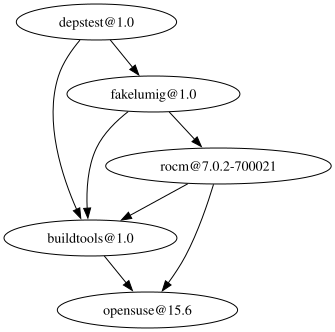

In [5]:
# Visualize the graph using pygraphviz
show_graph(graph, limit_node_info="name")  # only name and version (no hash/system/backend/distro/deps)
#show_graph(graph, limit_node_info="name_deps")  # only name, version and dependencies (no hash/system/backend/distro)
#show_graph(graph, save_path="dep_graph.png")  # full node info
